In [1]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,2676,2025-10-21 03:01:00,click,46,Women,Baggit Women Fighter Mayur Black Belt,Baggit,525.0,525.0,...,Black,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p>A belt is an essential detail to complete y...
1,1,2619,2025-10-21 03:02:00,click,46,Women,Baggit Women Blue Spirit Dum Belt,Baggit,575.0,575.0,...,Blue,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note </strong><br />A summer ...
2,1,1617,2025-10-21 03:05:00,click,46,Women,Baggit Women Flora Moly Red Belt,Baggit,500.0,500.0,...,Red,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note</strong><br /> A belt is...
3,1,8224,2025-10-21 03:04:00,click,46,Women,Baggit Women Brown Xylo Taj Belt,Baggit,575.0,575.0,...,Brown,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note </strong><br />A summer ...
4,1,1114,2025-10-21 03:17:00,click,46,Women,Wills Lifestyle Women Leather Blue Belt,Wills Lifestyle,999.0,649.0,...,Blue,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,"<div><span style=""font-family: tahoma, arial, ..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
seq_model_artifact = bentoml.models.get("transformer:latest")
reg_model_artifact = bentoml.models.get("regressor:latest")

seq_model_dir = Path(seq_model_artifact.path_of("artifact"))
reg_model_dir = Path(reg_model_artifact.path_of("artifact"))

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
0,8207,1,5,"[0, 0, 0, 0, 0]","[Provogue, Timberland, F Sports, ID, Provogue]","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Black, Tan, Black, Blue, Brown]","[Fall, Fall, Fall, Fall, Fall]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Footw...","[Shoes, Shoes, Shoes, Shoes, Shoes]","[Casual Shoes, Casual Shoes, Casual Shoes, Cas...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Everyday, <UNK>, Everyday, <UNK>, Everyday]","[purchase, click, click, click, click]","[1309, 9353, 178, 4056, 1537]","[9353, 178, 4056, 1537, 3346]"
1,8207,2,5,"[0, 0, 0, 0, 0]","[Provogue, Provogue, Timberland, F Sports, ID]","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Brown, Black, Tan, Black, Blue]","[Fall, Fall, Fall, Fall, Fall]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Footw...","[Shoes, Shoes, Shoes, Shoes, Shoes]","[Casual Shoes, Casual Shoes, Casual Shoes, Cas...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Everyday, Everyday, <UNK>, Everyday, <UNK>]","[purchase, purchase, click, click, click]","[1537, 1309, 9353, 178, 4056]","[1309, 9353, 178, 4056, 1537]"
2,8207,3,5,"[0, 0, 0, 0, 0]","[Timberland, Provogue, Provogue, Timberland, F...","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Brown, Brown, Black, Tan, Black]","[Fall, Fall, Fall, Fall, Fall]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Footw...","[Shoes, Shoes, Shoes, Shoes, Shoes]","[Casual Shoes, Casual Shoes, Casual Shoes, Cas...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, Everyday, Everyday, <UNK>, Everyday]","[click, purchase, purchase, click, click]","[1942, 1537, 1309, 9353, 178]","[1537, 1309, 9353, 178, 4056]"
3,8207,4,5,"[0, 0, 0, 0, 0]","[Numero Uno, Timberland, Provogue, Provogue, T...","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Black, Brown, Brown, Black, Tan]","[Fall, Fall, Fall, Fall, Fall]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Footw...","[Shoes, Shoes, Shoes, Shoes, Shoes]","[Casual Shoes, Casual Shoes, Casual Shoes, Cas...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, Everyday, Everyday, <UNK>]","[click, click, purchase, purchase, click]","[1231, 1942, 1537, 1309, 9353]","[1942, 1537, 1309, 9353, 178]"
4,8207,5,5,"[0, 0, 0, 0, 0]","[Numero Uno, Numero Uno, Timberland, Provogue,...","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Black, Black, Brown, Brown, Black]","[Fall, Fall, Fall, Fall, Fall]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Footw...","[Shoes, Shoes, Shoes, Shoes, Shoes]","[Casual Shoes, Casual Shoes, Casual Shoes, Cas...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, Everyday, Everyday]","[purchase, click, click, purchase, purchase]","[1940, 1231, 1942, 1537, 1309]","[1231, 1942, 1537, 1309, 9353]"
5,8207,6,5,"[0, 0, 0, 0, 0]","[Timberland, Numero Uno, Numero Uno, Timberlan...","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Brown, Black, Black, Brown, Brown]","[Fall, Fall, Fall, Fall, Fall]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Footw...","[Shoes, Shoes, Shoes, Shoes, Shoes]","[Casual Shoes, Casual Shoes, Casual Shoes, Cas...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, Everyday]","[wishlist, purchase, click, click, purchase]","[2901, 1940, 1231, 1942, 1537]","[1940, 1231, 1942, 1537, 13

In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 8207,
 'user_rn': 6,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Timberland',
  'Numero Uno',
  'Numero Uno',
  'Timberland',
  'Provogue'],
 'gender': ['Men', 'Men', 'Men', 'Men', 'Men'],
 'age_group': ['Adults-Men',
  'Adults-Men',
  'Adults-Men',
  'Adults-Men',
  'Adults-Men'],
 'base_color': ['Brown', 'Black', 'Black', 'Brown', 'Brown'],
 'season': ['Fall', 'Fall', 'Fall', 'Fall', 'Fall'],
 'year': ['2012', '2012', '2012', '2012', '2012'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'master_category': ['Footwear',
  'Footwear',
  'Footwear',
  'Footwear',
  'Footwear'],
 'sub_category': ['Shoes', 'Shoes', 'Shoes', 'Shoes', 'Shoes'],
 'article_type': ['Casual Shoes',
  'Casual Shoes',
  'Casual Shoes',
  'Casual Shoes',
  'Casual Shoes'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', 'Everyday'],
 'action': ['wishlist', 'purchase', 'click', 'click', 'purchase'],
 'item_id': [2901

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['wishlist', 'purchase', 'click', 'click', 'purchase'],
 'age_group': ['Adults-Men',
               'Adults-Men',
               'Adults-Men',
               'Adults-Men',
               'Adults-Men'],
 'article_type': ['Casual Shoes',
                  'Casual Shoes',
                  'Casual Shoes',
                  'Casual Shoes',
                  'Casual Shoes'],
 'base_color': ['Brown', 'Black', 'Black', 'Brown', 'Brown'],
 'brand_name': ['Timberland',
                'Numero Uno',
                'Numero Uno',
                'Timberland',
                'Provogue'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Men', 'Men', 'Men', 'Men', 'Men'],
 'master_category': ['Footwear',
                     'Footwear',
                     'Footwear',
                     'Footwear',
                     'Footwear'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', 'Everyday'],
 'season': ['Fall', 'Fall', 'Fall', 'Fall', 'Fall'],
 'sub_category': ['S

In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
# pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{5544: 0.9264719486236572,
 1856: 0.9232611060142517,
 3470: 0.921056866645813,
 7865: 0.920487105846405,
 4439: 0.9188212752342224,
 8594: 0.9165229797363281,
 7717: 0.9156625866889954,
 2939: 0.9151715636253357,
 1676: 0.914320170879364,
 1149: 0.9131518602371216,
 3389: 0.9127222895622253,
 6961: 0.9125803112983704,
 2187: 0.9123574495315552,
 3229: 0.9120798110961914,
 59: 0.9115360379219055,
 1499: 0.9114067554473877,
 4186: 0.9109539985656738,
 3512: 0.9104750752449036,
 2325: 0.909674346446991,
 2943: 0.9092395901679993,
 3442: 0.90900719165802,
 3479: 0.9089552164077759,
 4296: 0.9088448286056519,
 9321: 0.9088332056999207,
 4748: 0.9087498188018799,
 7861: 0.9085150957107544,
 6622: 0.905549943447113,
 5880: 0.9050000905990601,
 4651: 0.9045557975769043,
 9093: 0.9035672545433044}

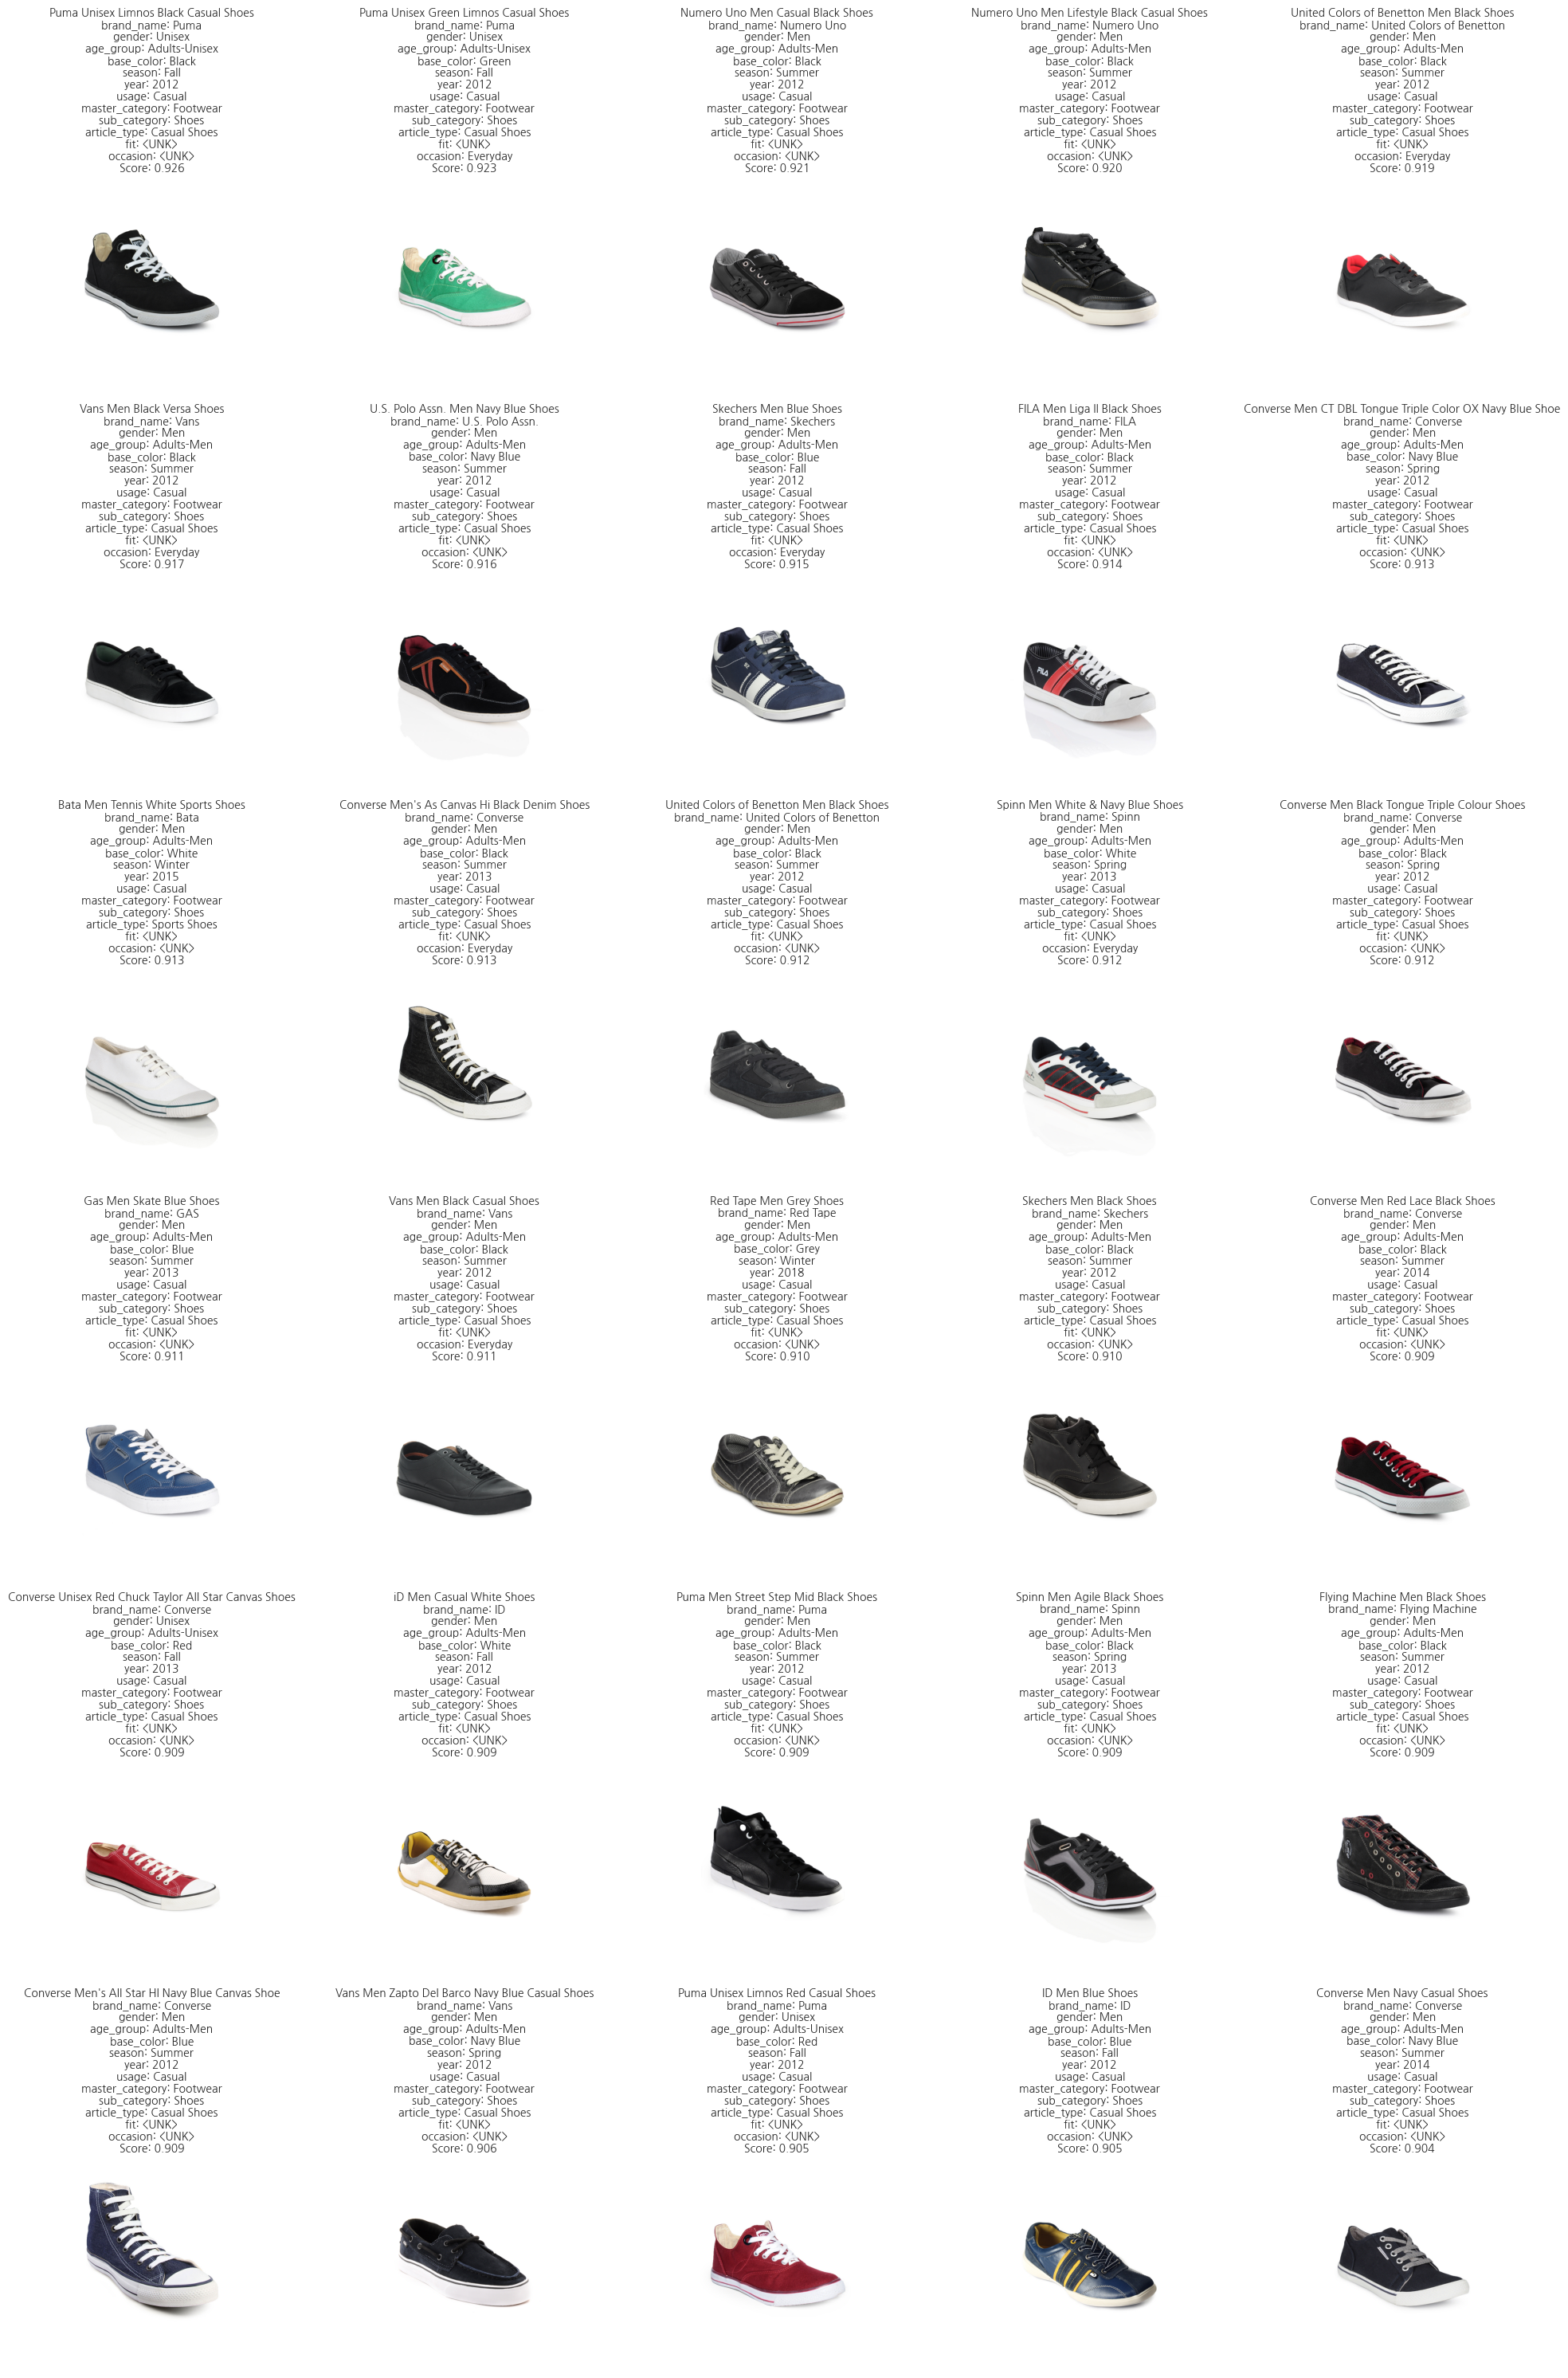

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.dataset_dir.joinpath("images"),
)